<a href="https://www.kaggle.com/code/lalit7881/diabetes-risk-prediction-80-75?scriptVersionId=345595737" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

# Imports and Setup
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # for matplotlib backend
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Setting seaborn style
sns.set(style='whitegrid')

# For reproducibility
RANDOM_STATE = 42
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/srisyra02/diabetes-risk-prediction-dataset/diabetes_risk_prediction_dataset.csv


## Loading dataset

In [2]:
# Helper function for resolving data files dynamically
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

# Testing the resolve of the diabetes dataset file
data_file = resolve_data_file(file_name='diabetes_risk_prediction_dataset.csv')
print(f'Resolved data file: {data_file}')

Resolved data file: /kaggle/input/datasets/srisyra02/diabetes-risk-prediction-dataset/diabetes_risk_prediction_dataset.csv


In [3]:
# Use the helper to resolve the data file path
data_file_path = resolve_data_file(file_name='diabetes_risk_prediction_dataset.csv')

# Load the dataset
df = pd.read_csv(data_file_path, encoding='ascii', delimiter=',')

print('Data loaded successfully.')
print(f'Dataset dimensions: {df.shape}')
df.head()

Data loaded successfully.
Dataset dimensions: (50000, 42)


,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk,BMI_CATEGORY
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate,Normal
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High,Obese
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High,Obese
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High,Overweight
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High,Obese


In [4]:
# Data Cleaning and Preprocessing

# Let's inspect the info and summary of our dataset
print('Dataset information:')
df.info()

print('\nSummary Statistics:')
display(df.describe(include='all'))

# Convert data types if needed
# Our dataset description suggests no dates, but if there were, we would parse accordingly

# Checking for missing values
missing_values = df.isnull().sum()
print('\nMissing values in each column:')
print(missing_values[missing_values > 0])

# Handle missing values if any (here we simply drop rows with missing target or fill missing values for numeric columns)
if missing_values.sum() > 0:
    # Fill numeric missing with median, for example
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    # For non-numeric, fill with mode
    non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
    for col in non_numeric_cols:
        df[col] = df[col].fillna(df[col].mode()[0])

# Encode categorical variables where necessary
# For simplicity, we will encode 'Diabetes_Risk' which is our target variable, along with encoding any other key categorical features if needed
target = 'Diabetes_Risk'
le_target = LabelEncoder()
df[target] = le_target.fit_transform(df[target])

# For our predictive model, we will use a subset of features (biometric and lifestyle related columns)
# Here, we pick some numeric ones and encode a few of the categorical ones.
features = [
    'Age', 'BMI', 'Waist_Circumference_cm', 'Blood_Glucose', 'HbA1c', 'Fasting_Blood_Sugar', 'Insulin_Level',
    'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides',
    'Heart_Rate', 'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Sleep_Hours', 'Daily_Water_Intake_L'
]

# In a full analysis, one might include more features and encode categorical variables as well if they influence risk

print('\nData cleaning and preprocessing completed.')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  50000 non-null  int64  
 1   Age                         49503 non-null  float64
 2   Gender                      50000 non-null  object 
 3   Country                     50000 non-null  object 
 4   Height_cm                   47055 non-null  float64
 5   Weight_kg                   47038 non-null  float64
 6   BMI                         50000 non-null  float64
 7   Waist_Circumference_cm      50000 non-null  float64
 8   Blood_Glucose               49041 non-null  float64
 9   HbA1c                       48026 non-null  float64
 10  Fasting_Blood_Sugar         50000 non-null  float64
 11  Insulin_Level               50000 non-null  float64
 12  Blood_Pressure_Systolic     50000 non-null  int64  
 13  Blood_Pres

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk,BMI_CATEGORY
count,50000.000000,49503.000000,50000,50000,47055.000000,47038.000000,50000.000000,50000.000000,49041.000000,48026.000000,...,50000,49000,50000,50000,50000.000000,50000.000000,50000,50000,50000,50000
unique,NaN,NaN,3,25,NaN,NaN,NaN,NaN,NaN,NaN,...,2,3,5,2,NaN,NaN,15,2,3,4
top,NaN,NaN,Male,Malaysia,NaN,NaN,NaN,NaN,NaN,NaN,...,No,Good,Business,Urban,NaN,NaN,Strict Blood Sugar Monitoring,Yes,High,Obese
freq,NaN,NaN,16718,2083,NaN,NaN,NaN,NaN,NaN,NaN,...,25071,16361,10167,25129,NaN,NaN,7481,46426,36593,24999
mean,25000.500000,53.871099,NaN,NaN,170.018814,87.457003,30.924056,99.960790,159.905245,8.488061,...,NaN,NaN,NaN,NaN,2.998842,74.043920,NaN,NaN,NaN,NaN
std,14433.901067,21.130148,NaN,NaN,14.457787,24.500358,10.290091,23.086579,52.040575,2.313758,...,NaN,NaN,NaN,NaN,1.152273,15.598327,NaN,NaN,NaN,NaN
min,1.000000,18.000000,NaN,NaN,145.000000,45.000000,11.900000,60.000000,70.000000,4.500000,...,NaN,NaN,NaN,NaN,1.000000,13.000000,NaN,NaN,NaN,NaN
25%,12500.750000,35.000000,NaN,NaN,157.600000,66.300000,22.700000,80.000000,114.700000,6.500000,...,NaN,NaN,NaN,NaN,2.000000,64.000000,NaN,NaN,NaN,NaN
50%,25000.500000,54.000000,NaN,NaN,170.000000,87.300000,30.000000,99.800000,159.900000,8.500000,...,NaN,NaN,NaN,NaN,3.000000,75.000000,NaN,NaN,NaN,NaN
75%,37500.250000,72.000000,NaN,NaN,182.600000,108.600000,37.800000,119.900000,205.100000,10.500000,...,NaN,NaN,NaN,NaN,4.000000,86.000000,NaN,NaN,NaN,NaN



Missing values in each column:
Age                         497
Height_cm                  2945
Weight_kg                  2962
Blood_Glucose               959
HbA1c                      1974
Total_Cholesterol          1000
HDL                        1000
LDL                        1000
Triglycerides              1000
Physical_Activity_Level     500
Exercise_Hours_Per_Week    1992
Daily_Walking_Minutes      1964
Sleep_Hours                2017
Medication_Adherence       1000
dtype: int64

Data cleaning and preprocessing completed.


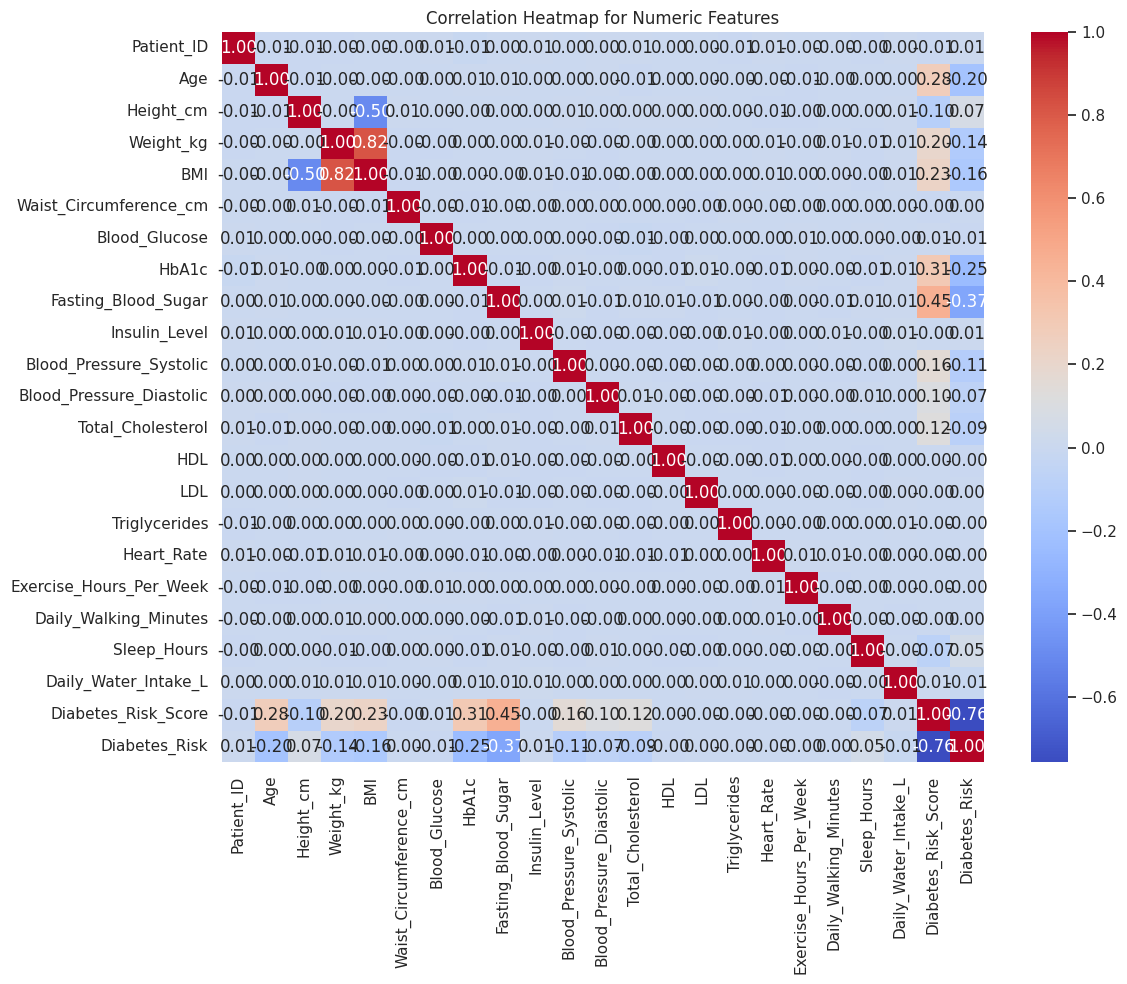

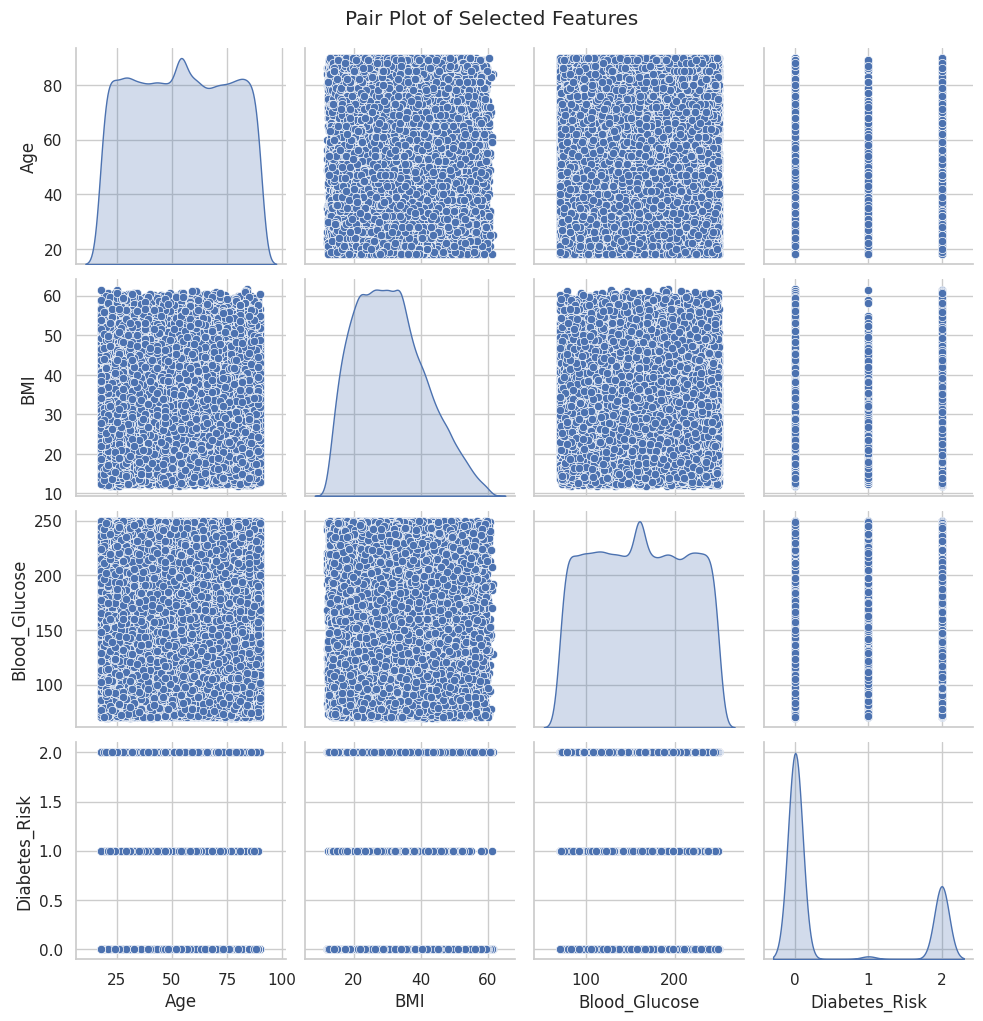

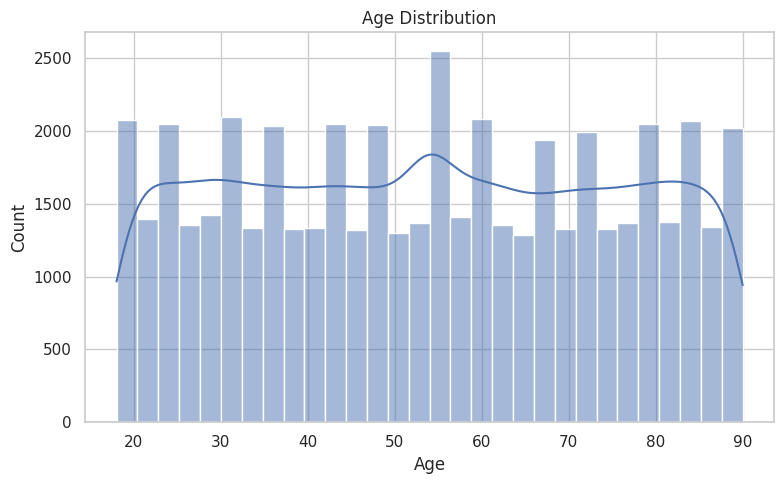

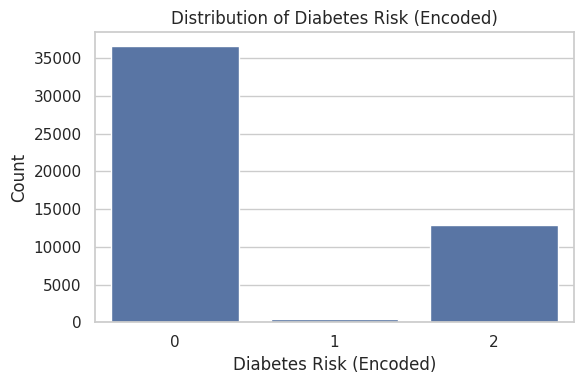

In [5]:
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(12,10))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap for Numeric Features')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for a correlation heatmap.')

## Pair Plot for a subset of numeric features
sample_features = ['Age', 'BMI', 'Blood_Glucose', target]
sns.pairplot(df[sample_features], diag_kind='kde')
plt.suptitle('Pair Plot of Selected Features', y=1.02)
plt.show()

## Histogram for Age
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Count Plot for Diabetes Risk Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=target, data=df)
plt.title('Distribution of Diabetes Risk (Encoded)')
plt.xlabel('Diabetes Risk (Encoded)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Accuracy Score: 0.8075


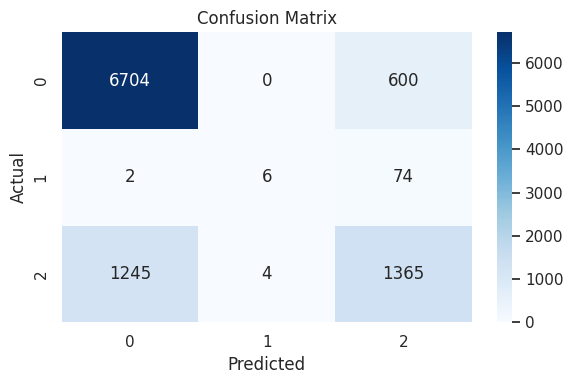

ROC Curve is not applicable for multiclass classification.


In [6]:
X = df[features]
y = df[target]

# It's often a good idea to scale numeric features for logistic regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=RANDOM_STATE)

# Initialize and train the model
model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {acc:.4f}')

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ROC Curve
if len(le_target.classes_) == 2:  # Only applicable for binary classification
    y_pred_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print('ROC Curve is not applicable for multiclass classification.')

## Thank you..pls upvote!!!!!!!!!